In [1]:
import sys, os

# ── Fijar working directory a la raíz del proyecto ──────────────────
# Solo subir si todavía estamos dentro de notebooks/
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print(f" Raíz del proyecto: {os.getcwd()}")
sys.path.insert(0, os.getcwd())  # asegura que src/ sea importable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from src.data_utils import load_config, load_raw_data, get_missing_summary
from src.visualization import plot_target_distribution, plot_correlation_heatmap

# ── Cargar config y datos ────────────────────────────────────────────
config = load_config("config/config.yaml")   # ← sin "..", ya estamos en la raíz
df = load_raw_data(config)
df.head(3)

 Raíz del proyecto: c:\Users\santi\Machine Learning\Proyecto
Dataset cargado: 20718 filas, 27 columnas


,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,-6.679,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,-5.815,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,-3.930,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07


In [2]:
threshold = config["viral_threshold"]

df["viral"] = (df["Stream"] >= threshold).astype(int)

print(df["viral"].value_counts())
print(df["viral"].value_counts(normalize=True))

viral
0    16026
1     4692
Name: count, dtype: int64
viral
0    0.77353
1    0.22647
Name: proportion, dtype: float64


In [3]:
print("=== FORMA DEL DATASET ===")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print("\n=== TIPOS DE DATOS ===")
print(df.dtypes.value_counts())
print("\n=== PRIMERAS FILAS ===")
df.head(3)

=== FORMA DEL DATASET ===
Filas: 20,718 | Columnas: 28

=== TIPOS DE DATOS ===
float64    15
object     12
int32       1
Name: count, dtype: int64

=== PRIMERAS FILAS ===


,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,...,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream,viral
0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,-6.679,...,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09,1
1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,-5.815,...,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08,1
2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,-3.930,...,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07,0


In [4]:

df[config["features_numericas"]].describe().round(3)

,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms
count,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000,20716.000
mean,0.620,0.635,5.300,-7.672,0.096,0.292,0.056,0.194,0.530,120.638,224717.579
std,0.165,0.214,3.576,4.633,0.112,0.286,0.193,0.169,0.245,29.579,124790.543
min,0.000,0.000,0.000,-46.251,0.000,0.000,0.000,0.014,0.000,0.000,30985.000
25%,0.518,0.507,2.000,-8.858,0.036,0.045,0.000,0.094,0.339,97.002,180009.500
50%,0.637,0.666,5.000,-6.536,0.050,0.193,0.000,0.125,0.537,119.965,213284.500
75%,0.740,0.798,8.000,-4.931,0.103,0.477,0.000,0.237,0.726,139.935,252443.000
max,0.975,1.000,11.000,0.920,0.964,0.996,1.000,1.000,0.993,243.372,4676058.000


In [5]:
missing = get_missing_summary(df)
print("=== VALORES FALTANTES ===")
print(missing if len(missing) > 0 else "✅ No hay valores faltantes significativos")

=== VALORES FALTANTES ===
                  Missing  Porcentaje (%)
Description           876            4.23
Stream                576            2.78
Comments              569            2.75
Likes                 541            2.61
Url_youtube           470            2.27
official_video        470            2.27
Licensed              470            2.27
Views                 470            2.27
Channel               470            2.27
Title                 470            2.27
Danceability            2            0.01
Energy                  2            0.01
Tempo                   2            0.01
Valence                 2            0.01
Liveness                2            0.01
Instrumentalness        2            0.01
Acousticness            2            0.01
Speechiness             2            0.01
Loudness                2            0.01
Key                     2            0.01
Duration_ms             2            0.01


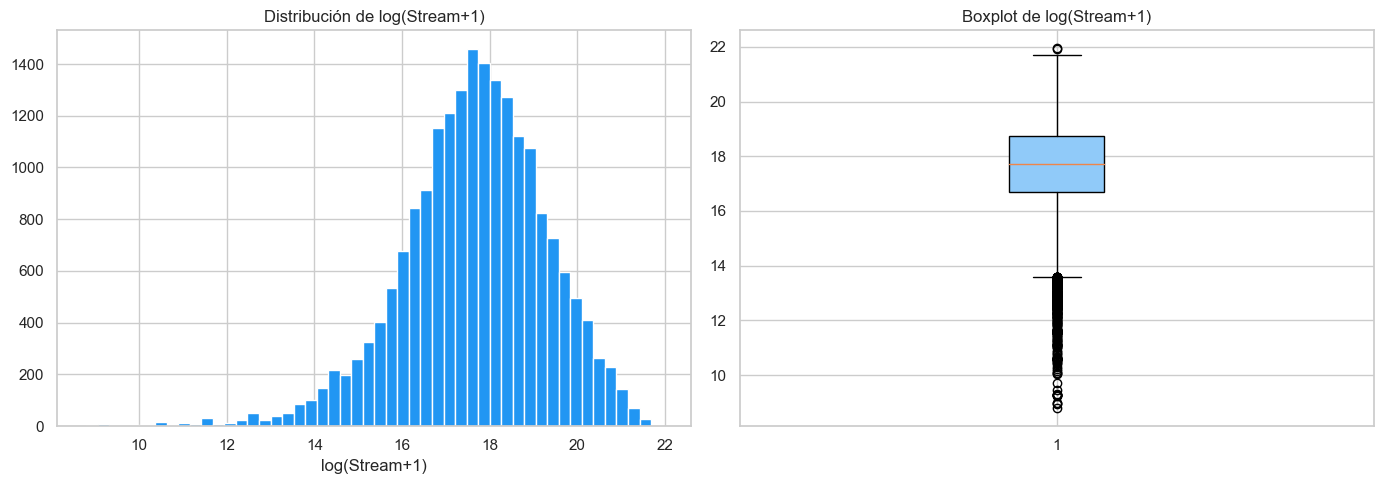

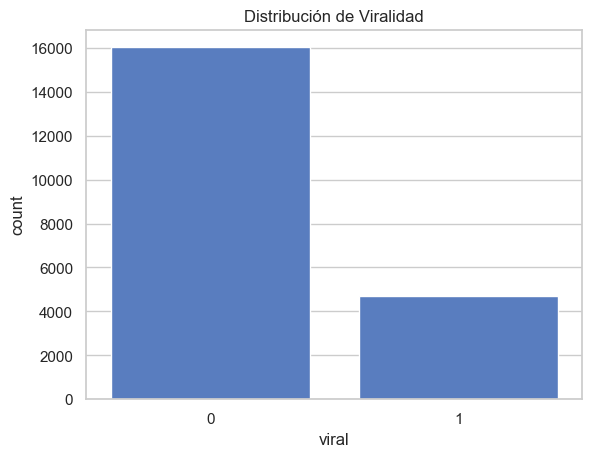

In [6]:

plot_target_distribution(df, "Stream", log=True)

sns.countplot(x="viral", data=df)
plt.title("Distribución de Viralidad")
plt.show()

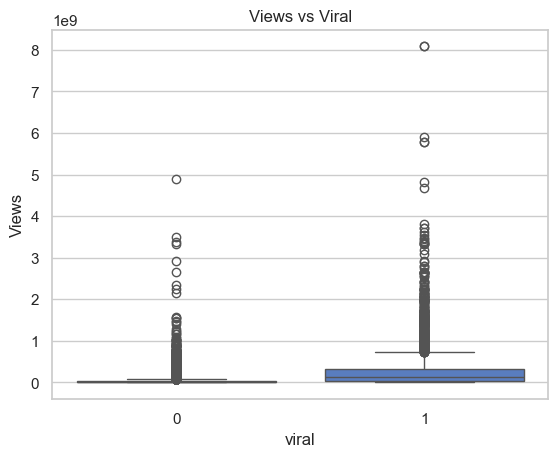

In [7]:
sns.boxplot(x="viral", y="Views", data=df)
plt.title("Views vs Viral")
plt.show()

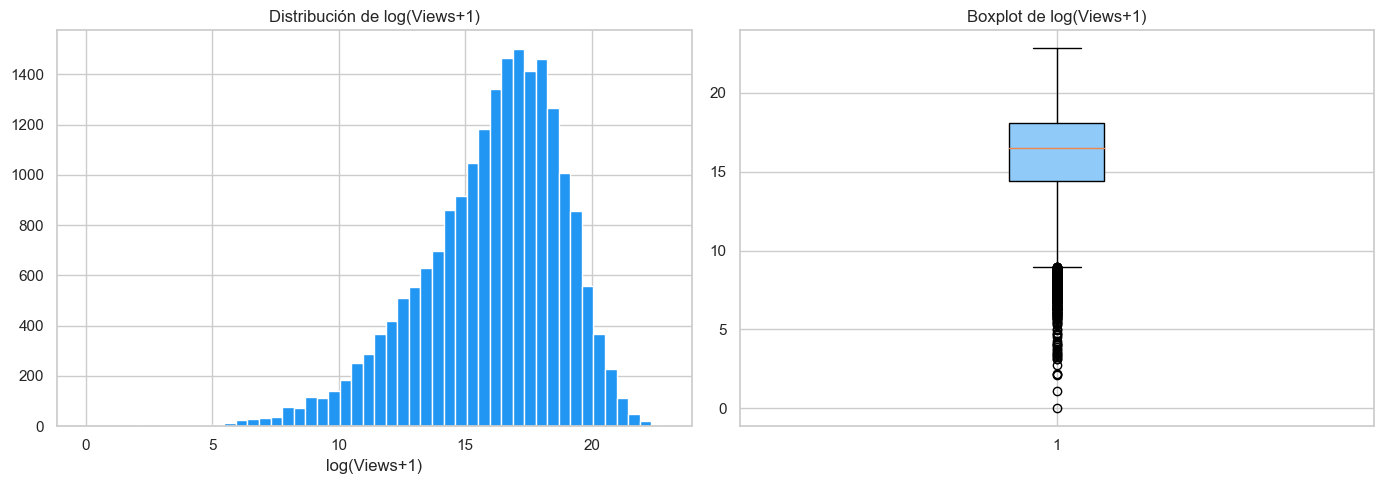

In [8]:

plot_target_distribution(df, "Views", log=True)

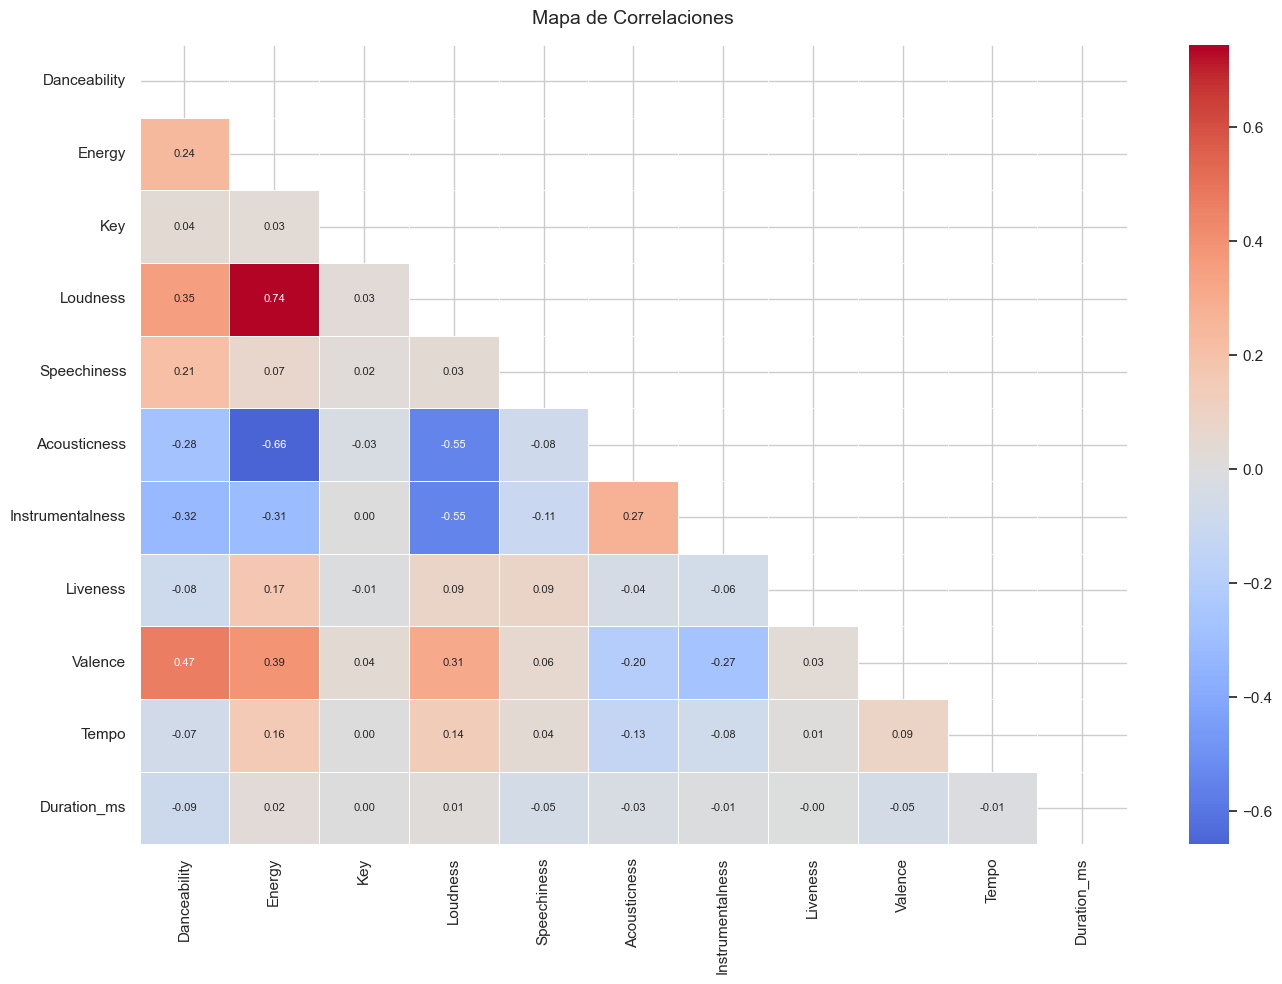

In [9]:

all_feats = config["features_numericas"]
plot_correlation_heatmap(df, [f for f in all_feats if f in df.columns])

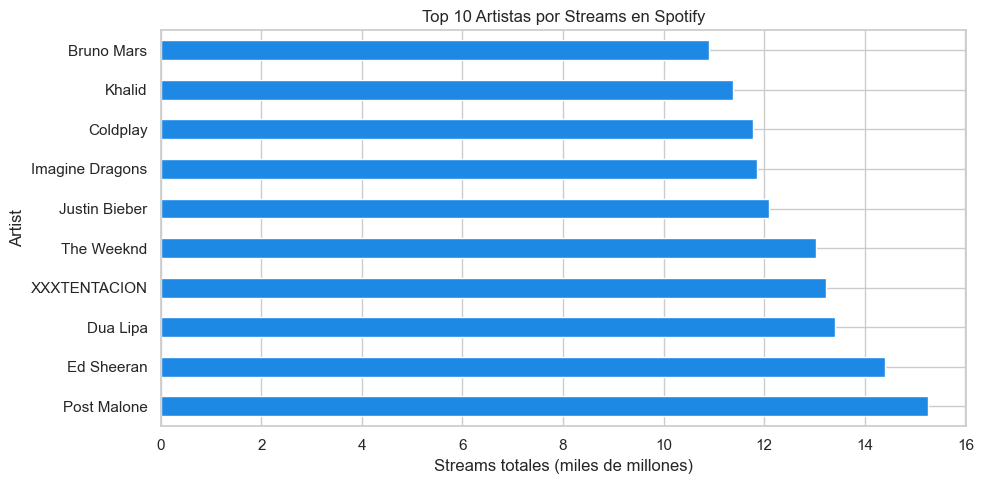

In [10]:
top_artists = (df.groupby("Artist")["Stream"]
               .sum()
               .sort_values(ascending=False)
               .head(10) / 1e9)
fig, ax = plt.subplots(figsize=(10, 5))
top_artists.plot(kind="barh", ax=ax, color="#1E88E5")
ax.set_xlabel("Streams totales (miles de millones)")
ax.set_title("Top 10 Artistas por Streams en Spotify")
plt.tight_layout()

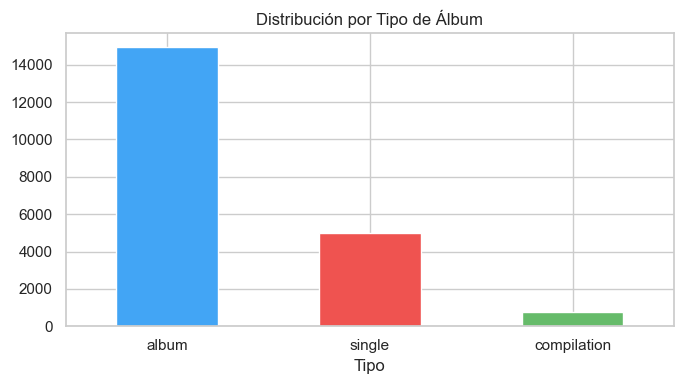

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
df["Album_type"].value_counts().plot(kind="bar", ax=ax, color=["#42A5F5","#EF5350","#66BB6A"])
ax.set_title("Distribución por Tipo de Álbum")
ax.set_xlabel("Tipo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("reports/figures/album_type_dist.png")
plt.show()

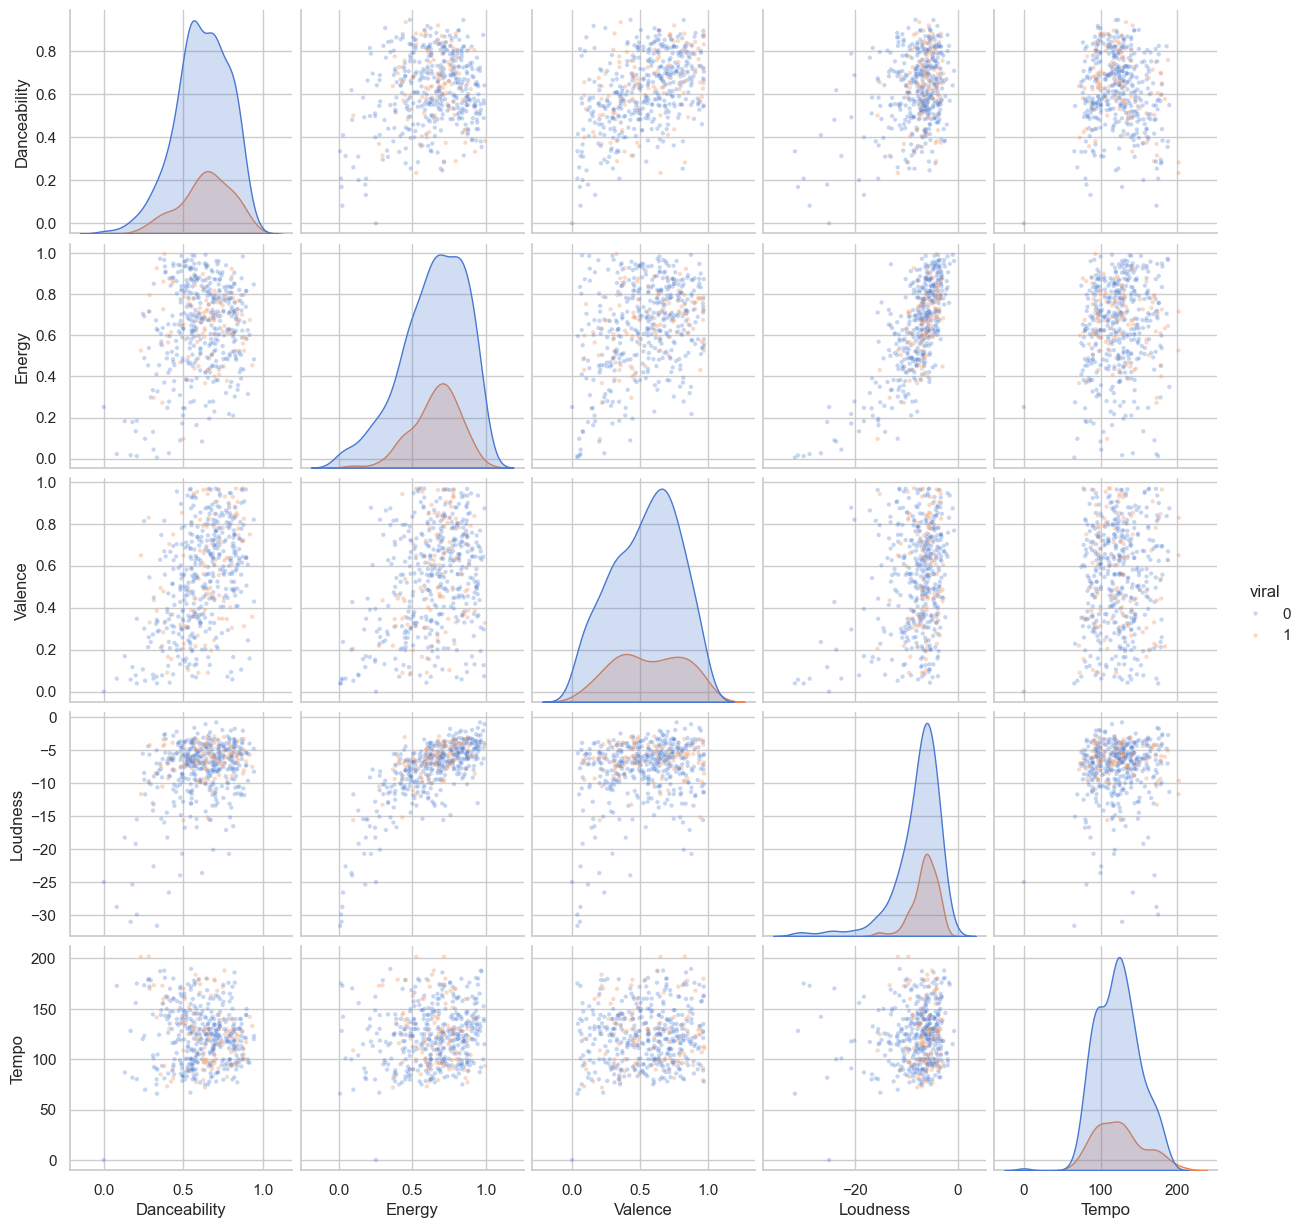

In [12]:
key_feats = ["Danceability","Energy","Valence","Loudness","Tempo","viral"]

sample = df[key_feats].dropna().sample(min(500, len(df)), random_state=42)

sns.pairplot(sample, hue="viral",
             diag_kind="kde",
             plot_kws={"alpha":0.3, "s":10})

plt.savefig("reports/figures/pairplot_features.png", dpi=150)
plt.show()